In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
A = pd.read_pickle("simulations_group.pkl", compression="bz2")

In [9]:
for ht in A.hash2.unique():
    BBB = A[A.hash2 == ht]
    print(ht)
    print( BBB.params.iloc[0][1].sum())

ai
5111
tokyo
4866
climate
5214
disease
6009


In [34]:
for ht in A.hash2.unique():
    BBB = A[A.hash2 == ht]
    print(ht)
    print( BBB.params.iloc[0][0].shape)

ai
(10005, 10005)
tokyo
(6580, 6580)
climate
(6729, 6729)
disease
(8394, 8394)


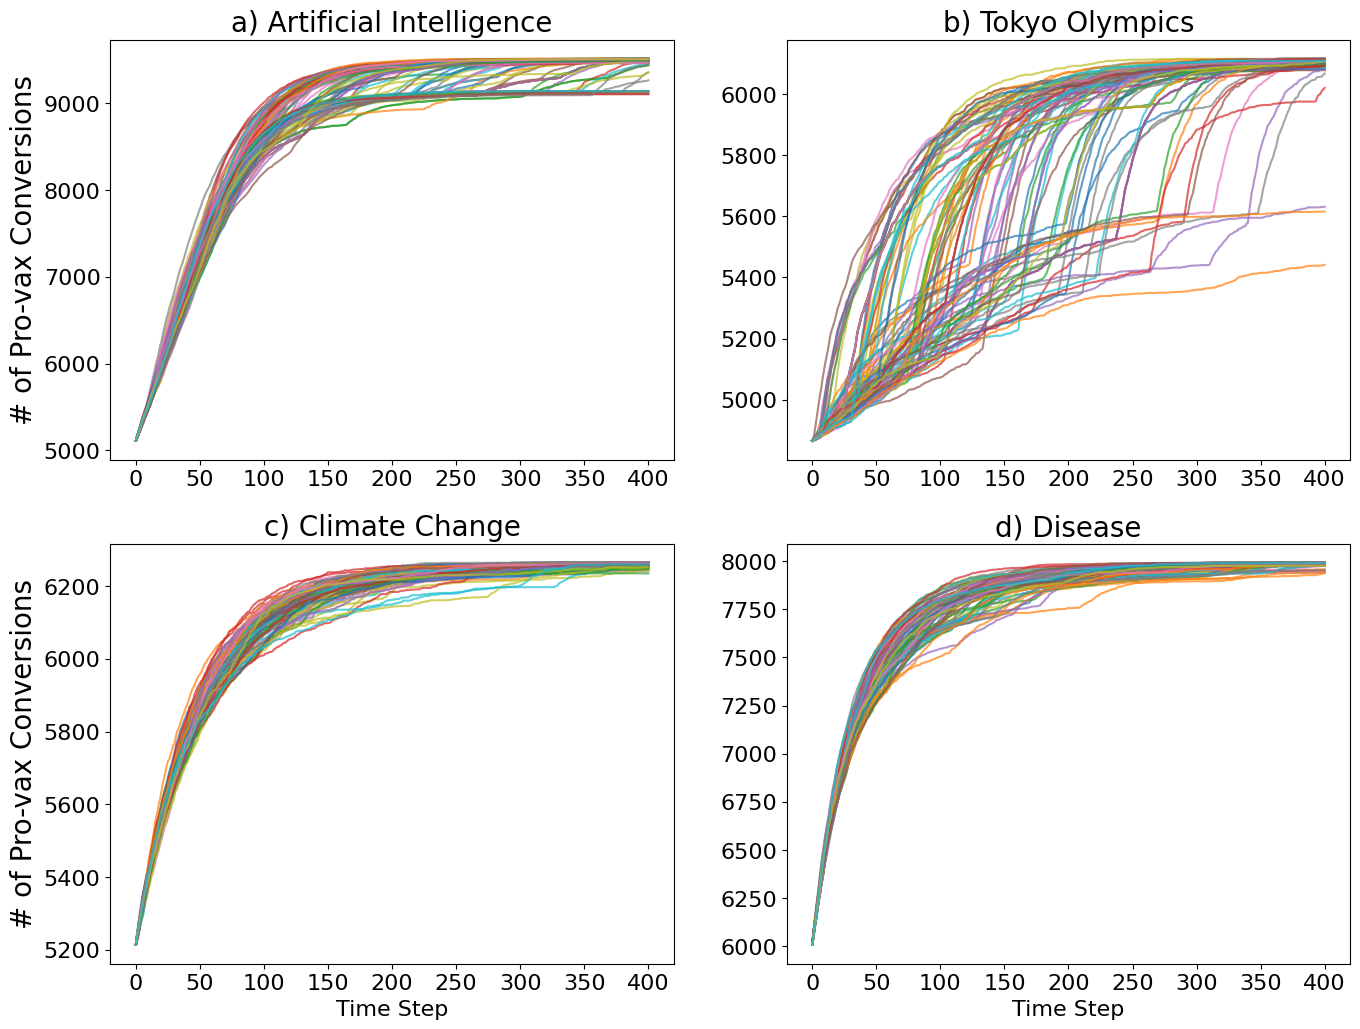

In [23]:
plt.figure(figsize=(16,12))
ranks = ["a) Artificial Intelligence", "b) Tokyo Olympics", "c) Climate Change", "d) Disease"]
for i,ht in enumerate(A.hash2.unique()):
    plt.subplot(2,2,i+1)
    B = A[A.hash2 == ht]
    for t in B.ts:
        plt.plot(t, alpha=0.7)
    plt.title(ranks[i] , fontsize=20)
    if (i % 2) == 0:
        plt.ylabel("# of Pro-vax Conversions", fontsize=20)
    if i > 1:
        plt.xlabel("Time Step", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

plt.savefig("figures/diffusion_no_dormancy.png", bbox_inches="tight")

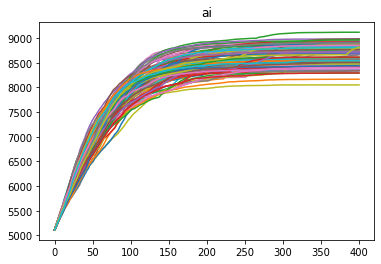

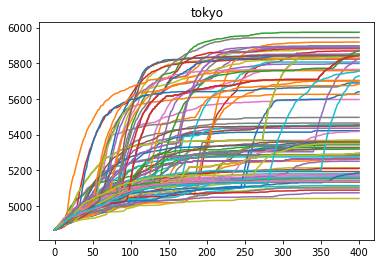

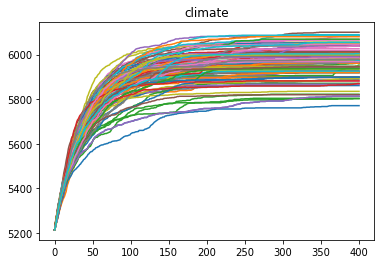

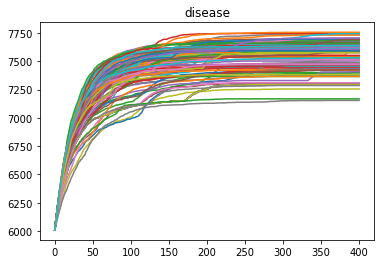

In [4]:
for ht in A.hash2.unique():
    B = A[A.hash2 == ht]
    plt.figure()
    for t in B.ts_dorm:
        plt.plot(t)
        plt.title(ht)

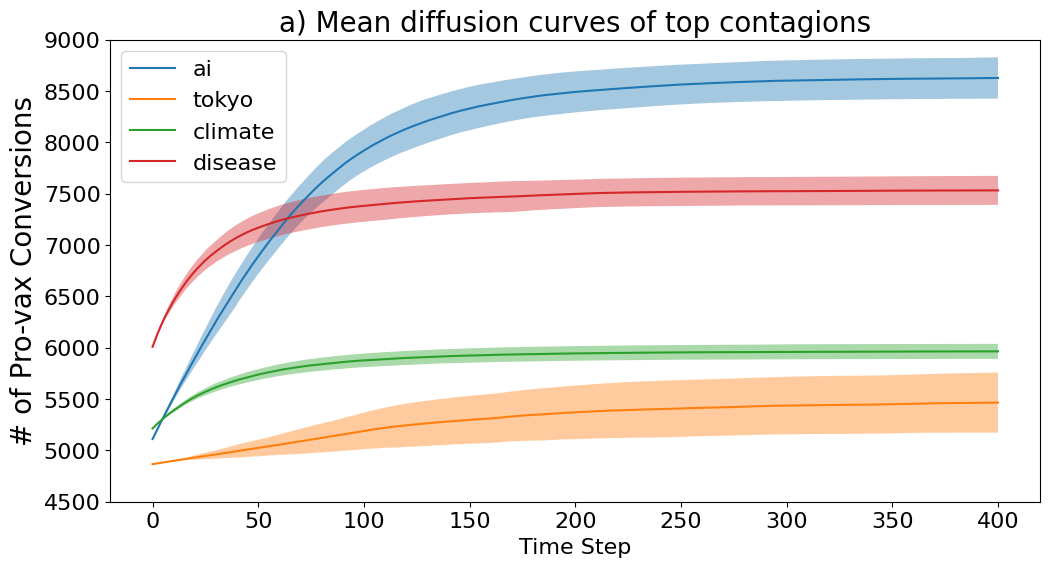

In [17]:
plt.figure(figsize=(12,6))
for ht in A.hash2.unique():
    B = A[A.hash2 == ht]
    
    means = np.mean( B.ts_dorm.values)
    std = np.std( B.ts_dorm.values ) 
    
    plt.plot(means, label= ht )
    plt.fill_between(np.arange(len(means)), means - std, means + std, alpha=0.4)

plt.legend(fontsize=16)
plt.ylim(4500,9000)

plt.ylabel("# of Pro-vax Conversions", fontsize=20)
plt.xlabel("Time Step", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("a) Mean diffusion curves of top contagions", fontsize=20)

plt.savefig("figures/diffusion_dormancy.png", bbox_inches="tight")

In [ ]:
Trade off between max depth, speed, and expected attention span. 

In [18]:
%%time
A["ts_max"]      = A.ts.apply(lambda x: x[-1])
A["ts_dorm_max"] = A.ts_dorm.apply(lambda x: x[-1])

A["ts_midstep"]      = A.ts.apply(lambda x: np.searchsorted(x, (x[-1]+x[0])/2, side='right'))
A["ts_dorm_midstep"] = A.ts_dorm.apply(lambda x: np.searchsorted(x, (x[-1]+x[0])/2, side='right'))

A["ts_gain"]      = A.ts.apply(lambda x: x[-1] - x[0])
A["ts_dorm_gain"] = A.ts_dorm.apply(lambda x: x[-1] - x[0])

A["gain_diff"] = A["ts_gain"] - A["ts_dorm_gain"]

CPU times: user 17.2 ms, sys: 5.89 ms, total: 23.1 ms
Wall time: 24.4 ms


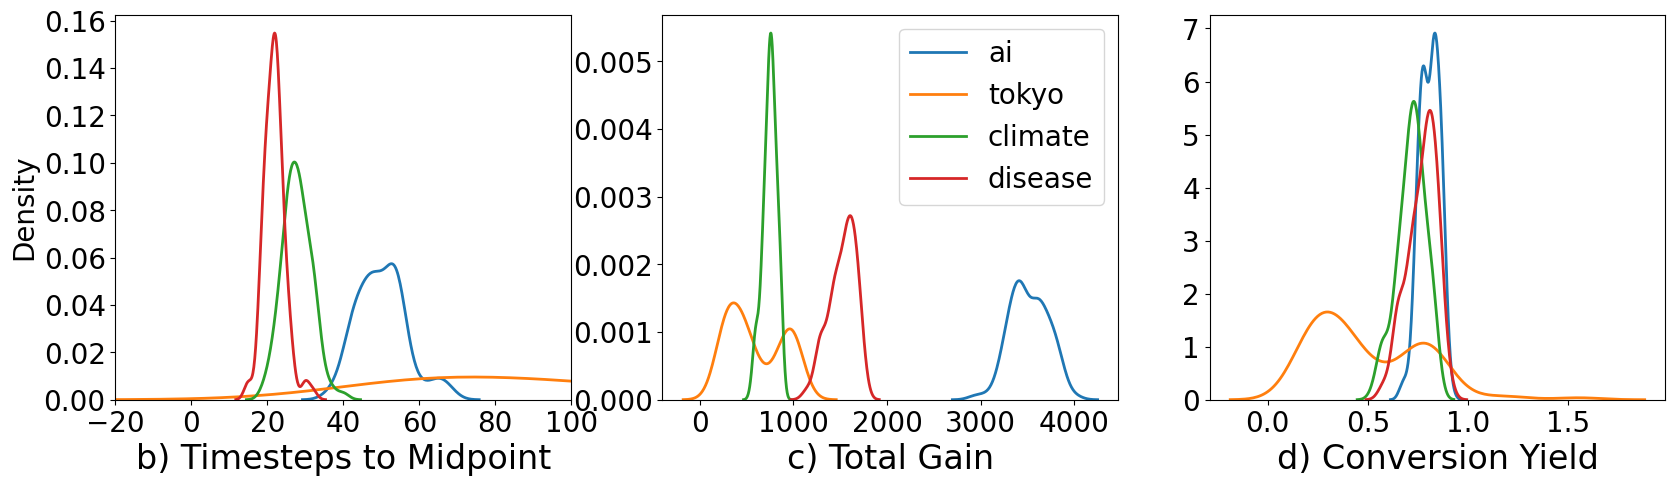

In [21]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
for i,ht in enumerate(A.hash2.unique()):
#     if ht=="tokyo":
#         continue
    sns.kdeplot( A[A.hash2 == ht].ts_dorm_midstep , label=ht , linewidth=2)
# plt.legend(fontsize=16)
plt.xlabel("b) Timesteps to Midpoint", fontsize=24)
plt.xlim(-20,100)
plt.ylabel("Density", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.subplot(1,3,2)
plt.xlabel("c) Total Gain", fontsize=24)
for i,ht in enumerate(A.hash2.unique()):
    sns.kdeplot( A[A.hash2 == ht].ts_dorm_gain , label=ht , linewidth=2)
plt.legend(fontsize=20)
plt.ylabel("")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.subplot(1,3,3)
plt.xlabel("d) Conversion Yield", fontsize=24)
for i,ht in enumerate(A.hash2.unique()):
    B = A[A.hash2 == ht]
    sns.kdeplot( B.ts_dorm_gain / B.ts_gain, label=ht , linewidth=2)
# plt.legend(fontsize=20)
plt.ylabel("")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.savefig("figures/density.png", bbox_inches="tight")
print("")

In [ ]:
Existing communities, rather than events, are more consistent.


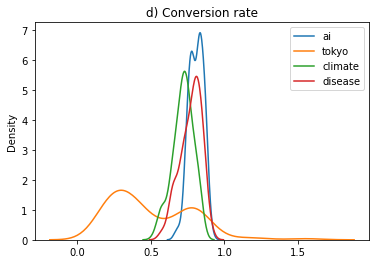

In [114]:
plt.title("d) Conversion rate")
for i,ht in enumerate(A.hash2.unique()):
    B = A[A.hash2 == ht]
    sns.kdeplot( B.ts_dorm_gain / B.ts_gain, label=ht )
plt.legend()

In [109]:
A.columns

Index(['hash2', 'params', 'ts', 'ts_dorm', 'ts_max', 'ts_dorm_max',
       'ts_midstep', 'ts_dorm_midstep', 'ts_gain', 'ts_dorm_gain',
       'gain_diff'],
      dtype='object')

In [86]:
nei   = A.params.iloc[0][0][0]
inf_s = A.params.iloc[0][1]
deg   = A.params.iloc[0][2]

In [106]:
overlap = ( (A.params.iloc[0][0] * inf_s).sum(axis=1) != deg ).sum()

In [102]:
nei.shape

(10005,)

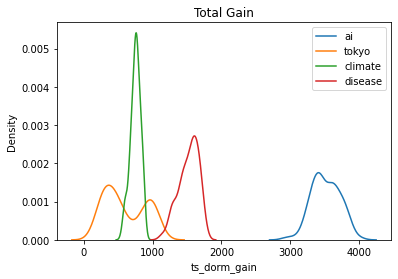

In [65]:
plt.figure()
plt.title("Total Gain")
for i,ht in enumerate(A.hash2.unique()):
    sns.kdeplot( A[A.hash2 == ht].ts_dorm_gain , label=ht )
plt.legend()

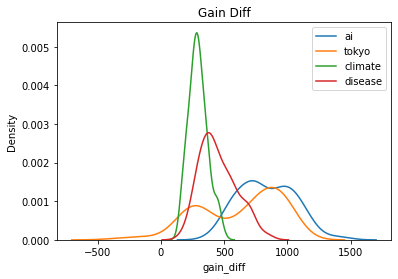

In [66]:
plt.figure()
plt.title("Gain Diff")
for i,ht in enumerate(A.hash2.unique()):
    sns.kdeplot( A[A.hash2 == ht].gain_diff , label=ht )
plt.legend()

In [ ]:
## Communities that take longer to diffuse in can also be suceptible to 

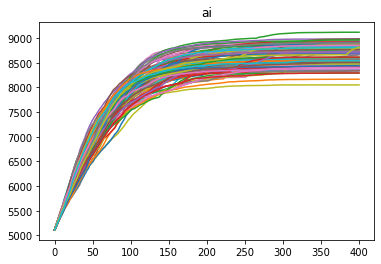

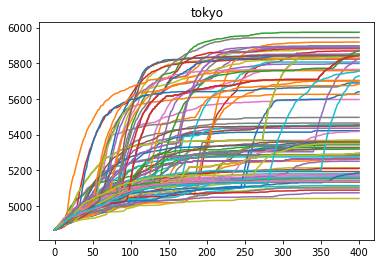

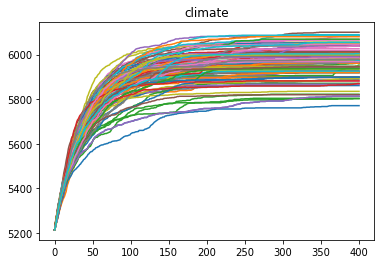

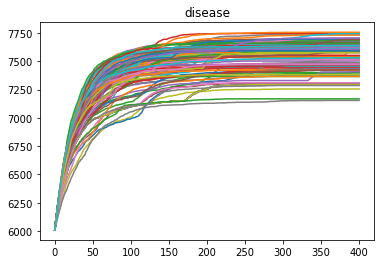

In [55]:
for ht in A.hash2.unique():
    B = A[A.hash2 == ht]
    plt.figure()
    for t in B.ts_dorm:
        plt.plot(t)
        plt.title(ht)